In [1]:
!bash -lc 'module load Miniforge3/24.1.2-0 && source $EBROOTMINIFORGE3/bin/activate && conda activate hycom-cice'
import xarray as xr

The following modules were not unloaded:
  (Use "module --force purge" to unload all):

  1) StdEnv


In [2]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from matplotlib.colors import TwoSlopeNorm

def ArcticMap():

    fig, ax = plt.subplots(
        figsize=(8, 8),
        subplot_kw={"projection": ccrs.NorthPolarStereo(central_longitude=0.0)},
    )

    ax.set_extent([-180, 180, 48, 90], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor=cfeature.COLORS["land"], edgecolor="grey", zorder=2)
    ax.add_feature(cfeature.COASTLINE.with_scale("50m"), edgecolor="grey", linewidth=0.4, zorder=3)
    ax.gridlines()
      
    return fig, ax
    
def pcolormesh_curvilinear(lon, lat, data, ax=None, **kwargs):

    proj = ax.projection
    pxy = proj.transform_points(ccrs.PlateCarree(), lon, lat)
    px, py = pxy[:, :, 0], pxy[:, :, 1]
    invalid = ~np.isfinite(px) | ~np.isfinite(py)
    px = np.where(invalid, 0.0, px)
    py = np.where(invalid, 0.0, py)
    data = np.where(invalid, np.nan, data)
    return ax.pcolormesh(px, py, data, **kwargs)


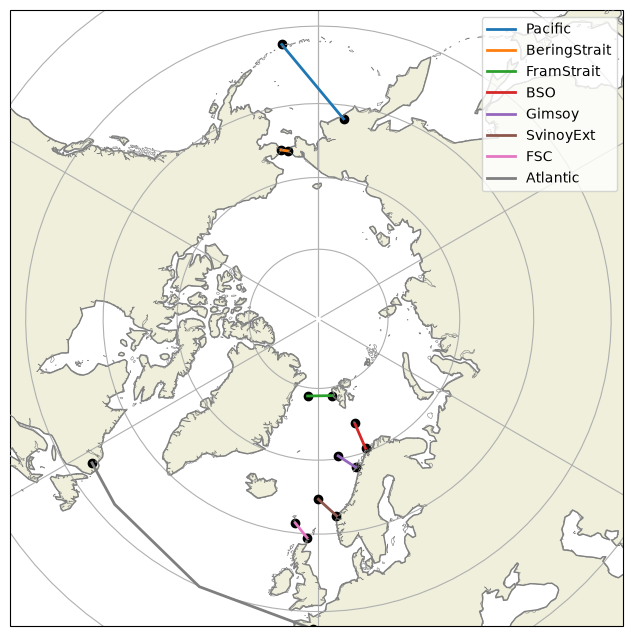

In [3]:
SECTIONS = {
    "Pacific": [
        {"lon": 172.83, "lat": 61.84},
        {"lon": -172.39, "lat": 52.02},
    ],
    "BeringStrait": [
        {"lon": -169.70, "lat": 66.00},
        {"lon": -167.47, "lat": 65.67},
    ],
    "FramStrait": [
        {"lon": 10.00, "lat": 78.83},
        {"lon": -8.00, "lat": 78.83},
    ],
    "BSO": [
        {"lon": 20.000, "lat": 70.50},
        {"lon": 19.167, "lat": 74.25},
    ],
    "Gimsoy": [
        {"lon": 8.200, "lat": 70.40},
        {"lon": 14.078, "lat": 68.406},
    ],
    "SvinoyExt": [
        {"lon": 5.200, "lat": 62.367},
        {"lon": 0.000, "lat": 64.667},
    ],
    "FSC": [
        {"lon": -3.000, "lat": 59.50},
        {"lon": -6.500, "lat": 61.33},
    ],
    "Atlantic": [
        {"lon": -0.92, "lat": 47.80},
        {"lon": -57.55, "lat": 53.10},
    ],
}

fig, ax = ArcticMap()

for name, pts in SECTIONS.items():
    lons = [p["lon"] for p in pts]
    lats = [p["lat"] for p in pts]

    # Handle sections crossing the dateline
    if max(lons) - min(lons) > 180:
        lons = [lon + 360 if lon < 0 else lon for lon in lons]

    # Plot endpoints
    ax.plot(lons, lats, "ko", transform=ccrs.PlateCarree())

    # Plot section
    ax.plot(
        lons,
        lats,
        lw=2,
        label=name,
        transform=ccrs.PlateCarree(),
    )

ax.legend()
plt.show()

In [4]:
refrun_file = "/cluster/work/users/arnelt/transport_test/transports2.nc"
run_file = "/cluster/work/users/arnelt/TP2a0.10/expt_93.0/data/transports2.nc"
runbias_file = "/cluster/work/users/arnelt/TP2a0.10/expt_93.1/data/transports2.nc"
time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)

ds_refrun = xr.open_dataset(refrun_file, decode_times=time_coder)
ds_run = xr.open_dataset(run_file, decode_times=time_coder)
ds_runbias = xr.open_dataset(runbias_file, decode_times=time_coder)

In [5]:
ds_run

<xarray.Dataset> Size: 139kB
Dimensions:              (transport: 8, N_2: 2, time: 1916)
Coordinates:
  * time                 (time) object 15kB 1993-11-02 12:00:00 ... 1999-01-3...
Dimensions without coordinates: transport, N_2
Data variables:
    sectionname          (transport) |S20 160B ...
    transportname        (transport) |S20 160B ...
    mask_variable_name   (transport) |S20 160B ...
    mask_variable_range  (transport, N_2) float32 64B ...
    section_lon          (transport, N_2) float32 64B ...
    section_lat          (transport, N_2) float32 64B ...
    direction            (transport) |S1 8B ...
    vol_transport        (time, transport) float32 61kB ...
    heat_transport       (time, transport) float32 61kB ...
Attributes:
    title:        TOPAZ transport across sections
    institution:  NERSC, Thormoehlens gate 47, N-5006 Bergen, Norway
    references:   http://topaz.nersc.no
    comment:      Transports are defined as positive if it is towards the rig...

Pacific             
Refrun mean: -0.26 Sv
Run mean: -0.08 Sv
Run with bias mean: -0.15 Sv
BeringStrait        
Refrun mean: -0.24 Sv
Run mean: -0.07 Sv
Run with bias mean: -0.14 Sv
FramStrait          
Refrun mean: -1.21 Sv
Run mean: -1.15 Sv
Run with bias mean: -1.16 Sv
BSO                 
Refrun mean: 2.39 Sv
Run mean: 1.98 Sv
Run with bias mean: 1.95 Sv
Gimsoy              
Refrun mean: -3.07 Sv
Run mean: -4.10 Sv
Run with bias mean: -4.22 Sv
SvinoyExt           
Refrun mean: 5.07 Sv
Run mean: 4.53 Sv
Run with bias mean: 4.41 Sv
FSC                 
Refrun mean: 1.00 Sv
Run mean: 0.36 Sv
Run with bias mean: 0.27 Sv
Atlantic            
Refrun mean: -2.50 Sv
Run mean: -0.07 Sv
Run with bias mean: -0.10 Sv


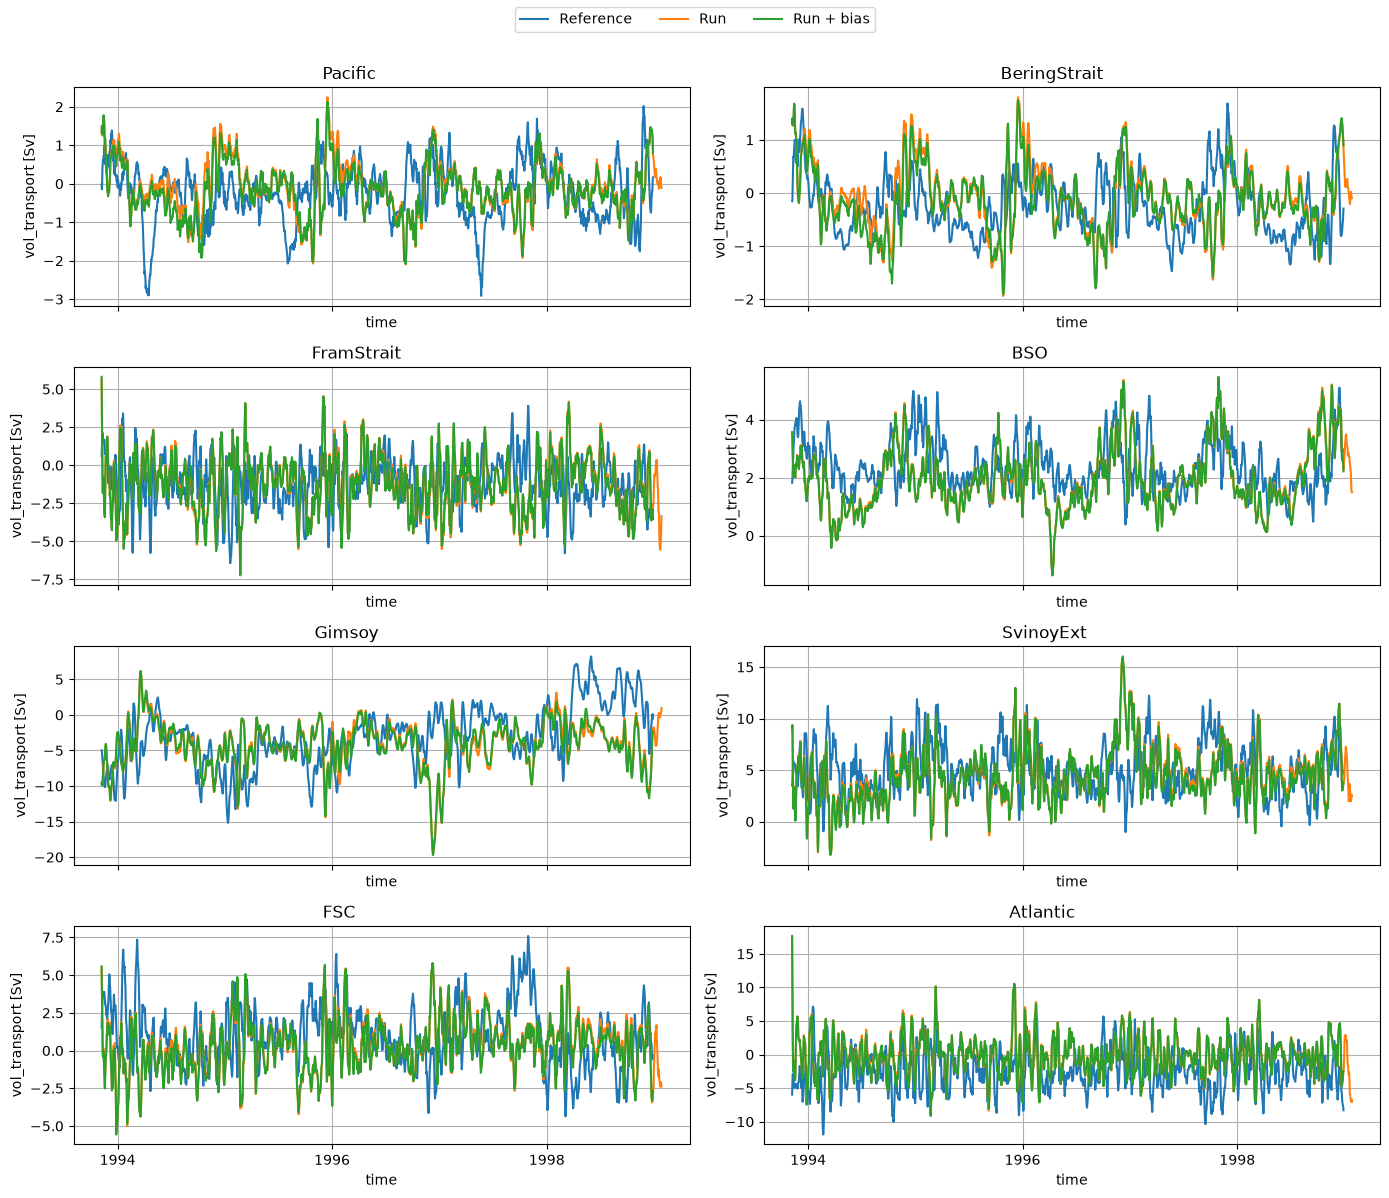

In [6]:
fig, axes = plt.subplots(4, 2, figsize=(14, 12), sharex=True)
axes = axes.flatten()

n_sections = ds_refrun.sizes["transport"]

for i, ax in enumerate(axes[:n_sections]):

    refrun = ds_refrun["vol_transport"].isel(transport=i)
    run = ds_run["vol_transport"].isel(transport=i)
    runbias = ds_runbias["vol_transport"].isel(transport=i)

    name = ds_refrun["sectionname"].isel(transport=i).values.item().decode("utf-8")

    print(name)
    print(f"Refrun mean: {refrun.mean().values:.2f} Sv")
    print(f"Run mean: {run.mean().values:.2f} Sv")
    print(f"Run with bias mean: {runbias.mean().values:.2f} Sv")

    refrun_smooth = refrun.rolling(time=10, center=True).mean()
    run_smooth = run.rolling(time=10, center=True).mean()
    runbias_smooth = runbias.rolling(time=10, center=True).mean()

    refrun_smooth.plot(ax=ax, label="Reference", add_legend=False)
    run_smooth.plot(ax=ax, label="Run", add_legend=False)
    runbias_smooth.plot(ax=ax, label="Run + bias", add_legend=False)

    ax.set_title(name)
    ax.grid(True)

# Hide any unused axes (if fewer than 8 sections)
for ax in axes[n_sections:]:
    ax.set_visible(False)

# Single legend for the whole figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3)

fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [ ]:
refrun2_file = "/cluster/work/users/arnelt/transport_test2/transports2.nc"
#runbias2_file = "/cluster/work/users/arnelt/TP2a0.10/expt_03.1/data/transports2.nc"
time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
ds_refrun2 = xr.open_dataset(refrun2_file, decode_times=time_coder)
#ds_runbias2 = xr.open_dataset(runbias2_file, decode_times=time_coder)

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(14, 12), sharex=True)
axes = axes.flatten()

n_sections = ds_refrun.sizes["transport"]

for i, ax in enumerate(axes[:n_sections]):

    refrun2 = ds_refrun2["vol_transport"].isel(transport=i)
    #runbias2 = ds_runbias2["vol_transport"].isel(transport=i)

    name = ds_refrun2["sectionname"].isel(transport=i).values.item().decode("utf-8")

    print(name)
    print(f"Refrun mean: {refrun2.mean().values:.2f} Sv")
    #print(f"Run with bias mean: {runbias2.mean().values:.2f} Sv")

    refrun2_smooth = refrun2.rolling(time=10, center=True).mean()
    #runbias2_smooth = runbias2.rolling(time=10, center=True).mean()

    refrun2_smooth.plot(ax=ax, label="Reference", add_legend=False)
    #runbias2_smooth.plot(ax=ax, label="Run + bias", add_legend=False)

    ax.set_title(name)
    ax.grid(True)

# Hide any unused axes (if fewer than 8 sections)
for ax in axes[n_sections:]:
    ax.set_visible(False)

# Single legend for the whole figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3)

fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()